## **2.4. Visualización sencilla de datos**

Para el desarrollo de las visualización trabajaremos con datos sobre los almacenes Walmart, que es un cadena de grande almacenes de Ewa. 

   ```{figure} /_image/walmart.png
   :align: center
   :name: Walmart
   :scale: 50
   ```

El conjunto de datos completos lo puede encontrar este [link](https://www.kaggle.com/datasets/yasserh/walmart-dataset/data). Trabajaremos un subconjunto de datos contiene las ventas semanales en dolares, cada tienda tiene un número de identificación y un tipo de tienda específico, las ventas estan separadas por ID de departamento. Junto con las ventas hay variables como si fue de vacaciones o no, la temperatura media durante la semana en esa localidad, el tiempo medio del combustible en dolares por litro esa semana y la tasa de desempleo de esa semana

Aquí tienes una explicación de las variables en el conjunto de datos de ventas proporcionado:

* **Unnamed**: Columna de índice que parece haber sido incluida al guardar el archivo. No es una variable significativa.

* **store**: Identificador del número de la tienda.

* **type**: Tipo de tienda, representado por una letra (por ejemplo, "A", "B", etc.).

* **department**: Identificador del número de departamento dentro de la tienda.

* **date**: Fecha en la que se registró la venta.

* **weekly_sales**: Ventas semanales en USD registradas en esa tienda y departamento específicos.

* **is_holiday**: Variable booleana que indica si la fecha corresponde a un día festivo o no. Los valores son "True" o "False".

* **temperature_c**: Temperatura en grados Celsius en la fecha registrada.

* **fuel_price_usd_per_l**: Precio del combustible en dólares estadounidenses por litro en la fecha registrada.

* **unemployment**: Tasa de desempleo en la fecha registrada.

Carguemos el conjunto de datos:

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd

filename = "_data/sales.csv"
df =  pd.read_csv(filename)
df.head()

,Unnamed: 0,store,type,department,date,weekly_sales,is_holiday,temperature_c,fuel_price_usd_per_l,unemployment
0,0,1,A,1,2010-02-05,24924.50,False,5.727778,0.679451,8.106
1,1,1,A,1,2010-03-05,21827.90,False,8.055556,0.693452,8.106
2,2,1,A,1,2010-04-02,57258.43,False,16.816667,0.718284,7.808
3,3,1,A,1,2010-05-07,17413.94,False,22.527778,0.748928,7.808
4,4,1,A,1,2010-06-04,17558.09,False,27.050000,0.714586,7.808


In [6]:
# Renombrar una columna
df.rename(columns={'Unnamed: 0': 'id'}, inplace=True)
df.head()

,id,store,type,department,date,weekly_sales,is_holiday,temperature_c,fuel_price_usd_per_l,unemployment
0,0,1,A,1,2010-02-05,24924.50,False,5.727778,0.679451,8.106
1,1,1,A,1,2010-03-05,21827.90,False,8.055556,0.693452,8.106
2,2,1,A,1,2010-04-02,57258.43,False,16.816667,0.718284,7.808
3,3,1,A,1,2010-05-07,17413.94,False,22.527778,0.748928,7.808
4,4,1,A,1,2010-06-04,17558.09,False,27.050000,0.714586,7.808


In [7]:
# Informacion del conjunto de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10774 entries, 0 to 10773
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10774 non-null  int64  
 1   store                 10774 non-null  int64  
 2   type                  10774 non-null  object 
 3   department            10774 non-null  int64  
 4   date                  10774 non-null  object 
 5   weekly_sales          10774 non-null  float64
 6   is_holiday            10774 non-null  bool   
 7   temperature_c         10774 non-null  float64
 8   fuel_price_usd_per_l  10774 non-null  float64
 9   unemployment          10774 non-null  float64
dtypes: bool(1), float64(4), int64(3), object(2)
memory usage: 768.2+ KB


**Matplotlib** es especialmente útil cuando necesitas crear gráficos personalizados y detallados, y es una herramienta esencial para cualquier persona que trabaje con visualización de datos en Python. Haremos unas gráficas univariadas

### **Histograma**

/opt/anaconda3/envs/ml_venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/anaconda3/envs/ml_venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


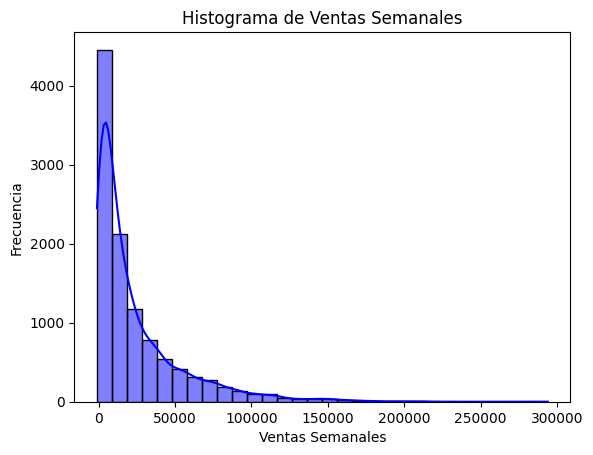

In [15]:
# importar matplotlib
import matplotlib.pyplot as plt

# Histograma de las ventas semanales
#plt.hist(df['weekly_sales'], bins=20, color='blue', alpha=0.7)
#plt.title('Histograma de Ventas Semanales')
#plt.xlabel('Ventas Semanales')
#plt.ylabel('Frecuencia')
#plt.show()

sns.histplot(df['weekly_sales'], bins=30, color='blue', kde=True)
plt.title('Histograma de Ventas Semanales')
plt.xlabel('Ventas Semanales')
plt.ylabel('Frecuencia')
plt.show()


In [16]:
df.weekly_sales.describe()

count     10774.000000
mean      23843.950149
std       30220.387557
min       -1098.000000
25%        3867.115000
50%       12049.065000
75%       32349.850000
max      293966.050000
Name: weekly_sales, dtype: float64

In [19]:
import numpy as np
import plotly.graph_objects as go
from scipy.stats import gaussian_kde

# Histograma
fig = go.Figure()

fig.add_trace(go.Histogram(
    x=df["weekly_sales"],
    nbinsx=30,
    histnorm="probability density",
    name="Histograma",
    opacity=0.7
))

# Curva KDE
x = np.linspace(df["weekly_sales"].min(),
                df["weekly_sales"].max(), 500)

kde = gaussian_kde(df["weekly_sales"])

fig.add_trace(go.Scatter(
    x=x,
    y=kde(x),
    mode="lines",
    name="KDE",
    line=dict(width=3)
))

fig.update_layout(
    title="Histograma de Ventas Semanales",
    xaxis_title="Ventas Semanales",
    yaxis_title="Densidad",
    template="plotly_white"
)

fig.show()

In [20]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Histogram(
    x=df["weekly_sales"],
    nbinsx=30,
    name="Frecuencia"
))

fig.update_layout(
    title="Histograma de Ventas Semanales",
    xaxis_title="Ventas Semanales",
    yaxis_title="Frecuencia",
    template="plotly_white"
)

fig.show()

In [21]:
import numpy as np
from scipy.stats import gaussian_kde
import plotly.graph_objects as go

# Datos
x = df["weekly_sales"].dropna()

# Número de bins
nbins = 30

# Calcular ancho de cada bin
bin_width = (x.max() - x.min()) / nbins

# Histograma
fig = go.Figure()

fig.add_trace(go.Histogram(
    x=x,
    nbinsx=nbins,
    name="Frecuencia",
    opacity=0.75
))

# KDE escalada a frecuencia
kde = gaussian_kde(x)

x_grid = np.linspace(x.min(), x.max(), 500)

# Escalar la densidad a frecuencias
y = kde(x_grid) * len(x) * bin_width

fig.add_trace(go.Scatter(
    x=x_grid,
    y=y,
    mode="lines",
    name="Distribución",
    line=dict(color="red", width=3)
))

fig.update_layout(
    title="Histograma de Ventas Semanales",
    xaxis_title="Ventas Semanales",
    yaxis_title="Frecuencia",
    template="plotly_white"
)

fig.show()

In [ ]:
# Importar seaborn
import seaborn as sns

# Histograma de las ventas semanales con Seaborn
# TU CODIGO AQUI
plt.show()

### **Densidad**


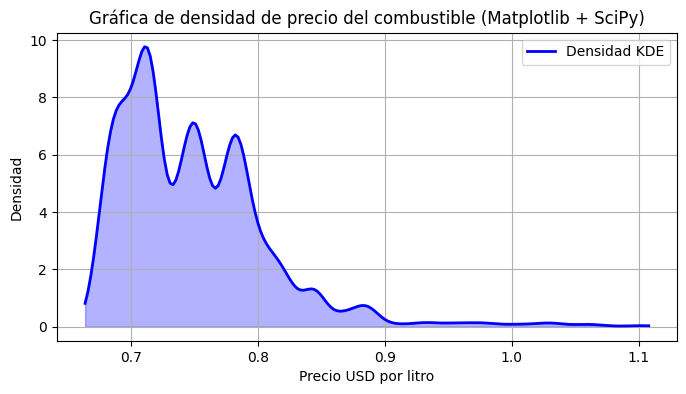

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Estimación de densidad usando KDE del precio del combustible
# fuel_price_usd_per_l

data = df['fuel_price_usd_per_l'].dropna()
kde = gaussian_kde(data)
x_vals = np.linspace(data.min(), data.max(), 200)
y_vals = kde(x_vals)



# Gráfico
plt.figure(figsize=(8, 4))
plt.plot(x_vals, y_vals, color='blue', lw=2, label='Densidad KDE')
plt.fill_between(x_vals, y_vals, alpha=0.3, color='blue')
plt.title('Gráfica de densidad de precio del combustible (Matplotlib + SciPy)')
plt.xlabel('Precio USD por litro')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
import numpy as np
import plotly.graph_objects as go
from scipy.stats import gaussian_kde

# Estimación de densidad usando KDE del precio del combustible
data = df['fuel_price_usd_per_l'].dropna()
kde = gaussian_kde(data)
x_vals = np.linspace(data.min(), data.max(), 200)
y_vals = kde(x_vals)

# Gráfico interactivo
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x_vals,
    y=y_vals,
    mode='lines',
    line=dict(color='blue', width=2),
    fill='tozeroy',                          # rellena hacia el eje x
    fillcolor='rgba(0, 0, 255, 0.3)',        # azul con transparencia
    name='Densidad KDE',
    hovertemplate='Precio: %{x:.3f} USD/L<br>Densidad: %{y:.3f}<extra></extra>'
))

fig.update_layout(
    title='Gráfica de densidad de precio del combustible (Plotly + SciPy)',
    xaxis_title='Precio USD por litro',
    yaxis_title='Densidad',
    width=800,
    height=400,
    template='plotly_white'
)

fig.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gráfico de densidad
plt.figure(figsize=(8, 4))
# tu codigo aquí
plt.title('Gráfica de densidad de precio del combustible (Seaborn)')
plt.xlabel('Precio USD por litro')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()


### **Histograma con función de densidad**

In [ ]:
# Gráfico
plt.figure(figsize=(8, 4))
# TU CODIGO AQUI
plt.title('Histograma con curva de densidad (Seaborn)')
plt.xlabel('Precio USD por litro')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()

* Una **transformación logarítmica** ayuda a identificar más tendencias. Por ejemplo, en el siguiente gráfico, el eje 
muestra los valores transformados en logaritmos de la variable del precio, y vemos que hay dos o más picos que indican el precio de la gasolina por litro

In [ ]:
# Datos transformados
log_data = # TU CODIGO AQUI
# Gráfico
plt.figure(figsize=(8, 4))
sns.histplot(log_data, kde=True, bins=30, color='lightgreen', edgecolor='black')
plt.title('Histograma con Curva de Densidad (Log Precios)')
plt.xlabel('Log(Precio USD por litro)')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()


### **Cajas y bigotes**

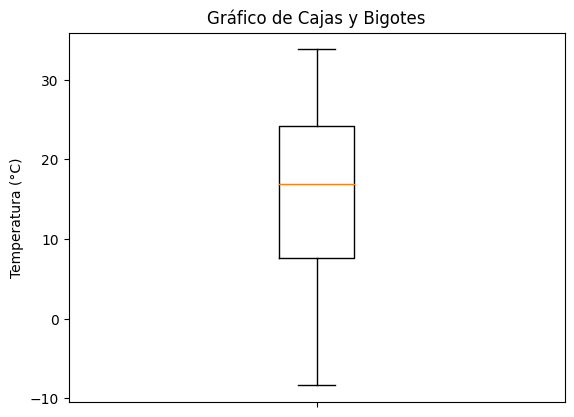

In [25]:
# diagrama de cajas y bigotes de la temperatura
plt.boxplot(df['temperature_c'].dropna())

# Remover el nombre de la columna del eje X
plt.xticks([1], [''])

# Agregar título y etiquetas
plt.title('Gráfico de Cajas y Bigotes')
plt.ylabel('Temperatura (°C)')

# Mostrar el gráfico
plt.show()


/opt/anaconda3/envs/ml_venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


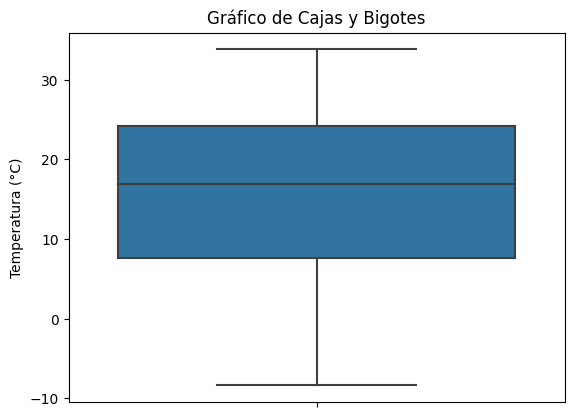

In [26]:
# Crear un diagrama de cajas y bigotes con Seaborn
sns.boxplot(y=df['temperature_c'].dropna())

# Remover el nombre de la columna del eje X
plt.xticks([0], [''])

# Agregar título y etiquetas
plt.title('Gráfico de Cajas y Bigotes')
plt.ylabel('Temperatura (°C)')

plt.show()


### **Barras**


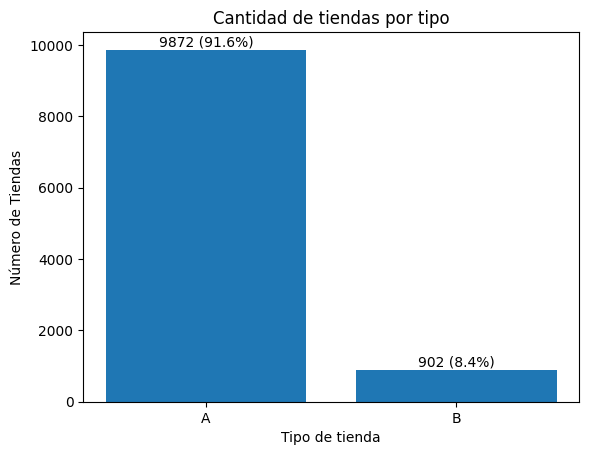

In [33]:
# Contar el tipo de tienda columna 'type'
tipo = df['type'].value_counts()

# Graficar el conteo de tipos de tienda en un gráfico de barras verticales
plt.bar(tipo.index, tipo.values)

# Agregar el conteo y el porcentaje sobre cada barra
total = tipo.sum()
for i, valor in enumerate(tipo.values):
    porcentaje = valor / total * 100
    plt.text(i, valor, f'{valor} ({porcentaje:.1f}%)', ha='center', va='bottom')

plt.title('Cantidad de tiendas por tipo')
plt.xlabel('Tipo de tienda')
plt.ylabel('Número de Tiendas')
plt.show()



/opt/anaconda3/envs/ml_venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/anaconda3/envs/ml_venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/anaconda3/envs/ml_venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


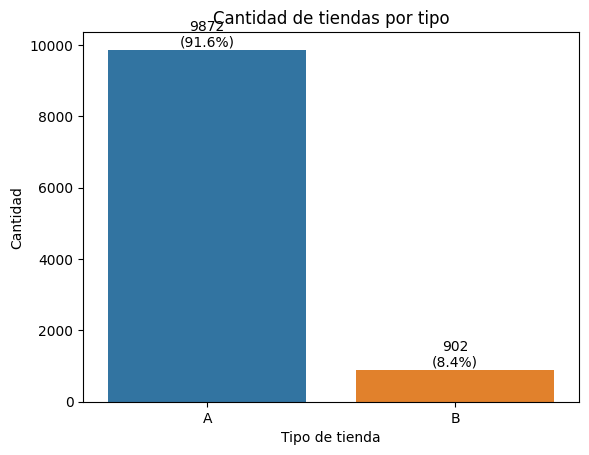

In [35]:
# Contar el tipo de tienda columna 'type'
tipo = df['type'].value_counts()

# Graficar con Seaborn
ax = sns.barplot(x=tipo.index, y=tipo.values)

# Agregar el conteo y el porcentaje sobre cada barra
total = tipo.sum()
for i, valor in enumerate(tipo.values):
    porcentaje = valor / total * 100
    ax.text(i, valor, f'{valor}\n({porcentaje:.1f}%)', ha='center', va='bottom')

plt.title('Cantidad de tiendas por tipo')
plt.xlabel('Tipo de tienda')
plt.ylabel('Cantidad')
plt.show()

In [ ]:
# Graficar el conteo de tipos de tienda en un gráfico de barras con Seaborn
# TU CODIGO AQUI

# Agregar título y etiquetas si lo deseas
plt.title('Conteo de tipos de tienda')
plt.xlabel('Tipo de tienda')
plt.ylabel('Frecuencia')

# Mostrar el gráfico
plt.show()

In [ ]:
# Contar el tipo de festividad
conteo_festivo =# TU CODIGO AQUI
conteo_festivo.columns = ['Festivo', 'Conteo']

# Graficar el conteo de festividades en un gráfico de barras horizontal con Seaborn
# TU CODIGO AQUI

# Agregar título y etiquetas si lo deseas
plt.title('Conteo de festividades')
plt.xlabel('Conteo')
plt.ylabel('Festivo')

# Mostrar el gráfico
plt.show()

### **Otras forma de realizar gráficos de barras**

Aprenderemos a crear una tabla utilizando la función `pandas crosstab`. Utilizaremos una tabla para generar un gráfico de barras. A continuación, exploraremos un gráfico de barras generado con la biblioteca `seaborn` y calcularemos la distribución del promedio de `weekly_sales` según el `store`. Para ello, vamos a realizar los siguientes pasos:


* Imprime los valores únicos de la columna corte. usemos `unique()` devuelve un array. El número de valores únicos se puede obtener utilizando `nunique()` en `pandas`.

In [ ]:
print(# TU CODIGO AQUI)
print(df.store.nunique())

* Para obtener los recuentos de las stores, primero creamos una tabla utilizando la función **pandas crosstab()**:

In [ ]:
store_count_table = # TU CODIGO AQUI
store_count_table

* Generemos el mismo gráfico con `seaborn`

In [ ]:
# Preparar los datos
store_counts = store_count_table.reset_index()

# Graficar
plt.figure(figsize=(10, 5))
# TU CODIGO AQUI
plt.title('Conteo de registros por tienda (desde tabla)')
plt.xlabel('Tienda')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

* Usemos `catplot` de `seaborn`

In [ ]:
sns.catplot(data = df, x = 'store', aspect = 1.5, kind = "count", color = "b");

Observe cómo la función `catplot()` no requiere que creemos la tabla de recuento intermedia (utilizando `pd.crosstab()`), y reduce un paso en el proceso de trazado.

* A continuación, se muestra cómo se obtiene la **distribución del precio medio semanal** de las diferentes calidades de **tiendas** utilizando `seaborn`

In [ ]:
from numpy import median, mean

sns.set(style = "whitegrid")
ax = sns.barplot(x = # TU CODIGO AQUI, y = # TU CODIGO AQUI, data = df, estimator = mean,color="skyblue");

Aquí, las líneas negras (barras de error) de los rectángulos indican la incertidumbre (o dispersión de los valores) en torno a la estimación de la media. Las funciones mencionadas van mucho más allá de un simple recuento: aplican una función que calcula una medida de tendencia central (por defecto es el valor medio) y muestran, aplicando `bootstrapping`, el intervalo de confianza del $95%$ para dicha medida. Por defecto, este valor está fijado en un $95%$ de confianza. ¿Cómo lo cambiamos? Utilizando el parámetro **ci=68**, por ejemplo, lo fijamos en el $68%$. También podemos representar la desviación estándar en los precios utilizando **ci=sd**.

* Reordenar las barras del eje x utilizando el orden:

In [ ]:
ax = sns.barplot(x = # TU CODIGO AQUI, y = # TU CODIGO AQUI, data = df, estimator = mean, ci = 68,color="#8FD694",
                 order = [31, 39,19, 1, 6,27, 13, 10,4, 2, 20, 14]);

* Ahora, veamos un gráfico de barras agrupada. Utilice el parámetro `hue` para trazar grupos anidados:

In [ ]:
ax = sns.barplot(x = # TU CODIGO AQUI, y = # TU CODIGO AQUI, hue = # TU CODIGO AQUI, data = df, estimator = mean,);

* Si deseamos poner notas en diagrama de barras.

In [ ]:
from numpy import mean
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x="store",
    y="weekly_sales",
    data=df,
    estimator=mean,
    color="#8FD694"
)

# Encuentra la tienda con mayores ventas promedio
mean_sales = df.groupby("store")["weekly_sales"].mean()
top_store = mean_sales.idxmax()
top_value = mean_sales.max()
x = list(mean_sales.index).index(top_store)  # posición de la barra en el eje x
y = top_value  # altura de la barra

# Anotación con nota visual
plt.annotate(
    'Excelente desempeño máximas ventas promedio',
    xy=(x, y),
    xytext=(x + 0.5, y + 2000),
    bbox=dict(boxstyle='round,pad=0.5', fc='lightyellow', ec='gold', lw=1.5),
    fontsize=10,
    arrowprops=dict(arrowstyle='->', color='red',linewidth=2),
)

plt.title("Promedio de ventas semanales por tienda")
plt.xlabel("Tienda")
plt.ylabel("Weekly Sales")
plt.show()


### **Circulares**

In [ ]:
tipo = # TU CODIGO AQUI

# Graficar el conteo de tipos de tienda en un diagrama circular
plt.pie(tipo, labels=tipo.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired(range(len(tipo))))
plt.title('Distribución de tipos de tienda')
plt.show()

### **Lineas**

In [ ]:
# Convertir la columna date a formato de fecha
df['date'] = # TU CODIGO AQUI

# Agrupar las ventas por fecha, sumando las ventas semanales en las fechas repetidas
df_grouped = df.groupby('date').agg({'weekly_sales': 'sum'}).reset_index()

df_grouped.head()

In [ ]:
# Crear un gráfico de líneas con las fechas agrupadas utilizando Seaborn
plt.figure(figsize=(12, 6))  # Ajustar el tamaño del gráfico
# tu codigo aquí

# Rotar las etiquetas del eje X para que se muestren en vertical
plt.xticks(rotation=90)

# Agregar título y etiquetas si lo deseas
plt.title('Ventas semanales agrupadas por fecha')
plt.xlabel('Fecha')
plt.ylabel('Ventas semanales')

# Mostrar el gráfico
plt.show()

### **Dispersión (Scatter Plots)**

In [ ]:
# Crear una gráfica de dispersión de ventas semanales vs. precio de la gasolina utilizando Seaborn
plt.figure(figsize=(10, 6))  # Ajustar el tamaño del gráfico
# TU CODIGO AQUI

# Agregar título y etiquetas
plt.title('Relación entre ventas semanales y precio de la gasolina')
plt.xlabel('Ventas semanales ($)')
plt.ylabel('Precio de la gasolina (USD por litro)')

# Mostrar el gráfico
plt.show()

### **Histogramas con variable categórica**

Para hacer estos histogramas debemos tener una variable numérica según una variable categórica

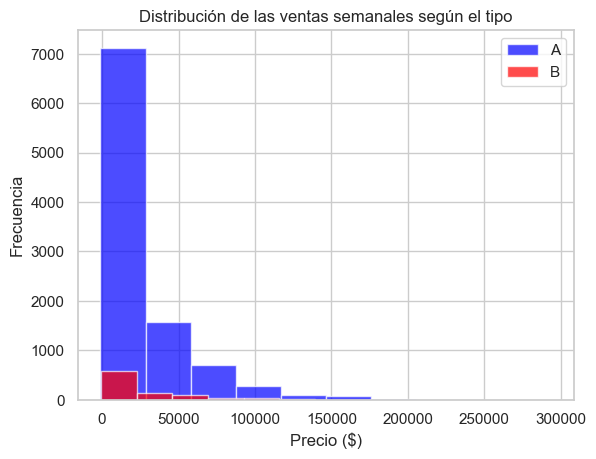

In [119]:
# Crear una superposición de histogramas
df[df['type'] == 'A']['weekly_sales'].hist(alpha=0.7, color='blue')
df[df['type'] == 'B']['weekly_sales'].hist(alpha=0.7, color='red')
plt.legend(['A', 'B'])
plt.title('Distribución de las ventas semanales según el tipo')
plt.xlabel('Precio ($)')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
# Crear una superposición de histogramas de las ventas semanales según el tipo de tienda utilizando Seaborn
plt.figure(figsize=(10, 6))  # Ajustar el tamaño del gráfico

# Histograma para el tipo 'A'
sns.histplot(# TU CODIGO AQUI, color='blue', label='A', kde=False, alpha=0.7)

# Histograma para el tipo 'B'
sns.histplot(# TU CODIGO AQUI, color='red', label='B', kde=False, alpha=0.7)

# Agregar título y etiquetas
plt.title('Distribución de las ventas semanales según el tipo')
plt.xlabel('Ventas semanales ($)')
plt.ylabel('Frecuencia')

# Mostrar la leyenda
plt.legend()

### **Cajas y bigotes con variable categórica**

Para hacer estos diagramas de cajas y bigotes debemos tener una variable numérica según una variable categórica

In [ ]:
# Separar los datos por sexo
u_a = # TU CODIGO AQUI
u_b = # TU CODIGO AQUI

# Crear un diagrama de cajas y bigotes para 'height_cm' vs 'sex' usando pandas
plt.boxplot([u_a, u_b], labels=['A', 'B'])

# Agregar título y etiquetas
plt.title('Diagrama de cajas y bigotes: tasa de desempleo según el tipo')
plt.xlabel('Sexo')
plt.ylabel('Altura (cm)')

# Mostrar el gráfico
plt.show()

In [ ]:
# Crear un diagrama de cajas y bigotes para 'unemployment' vs 'type' usando Seaborn
plt.figure(figsize=(10, 6))  # Ajustar el tamaño del gráfico

# TU CODIGO AQUI

# Agregar título y etiquetas
plt.title('Diagrama de cajas y bigotes: tasa de desempleo según el tipo')
plt.xlabel('Tipo de tienda')
plt.ylabel('Tasa de desempleo')

# Mostrar el gráfico
plt.show()

* ¿Y si pudiéramos obtener una pista sobre la distribución completa de una característica numérica específica agrupada por otras características categóricas? El tipo de técnica de visualización adecuada en este caso es un **gráfico de violín**. Un gráfico de violín es similar a un grafico de caja pero incluye más detalles sobre las variaciones de los datos.

In [ ]:
# Crear un diagrama de violín para 'unemployment' vs 'type'
plt.figure(figsize=(10, 6))  # Tamaño del gráfico

# tu codigo aquí

# Agregar título y etiquetas
plt.title('Distribución de la tasa de desempleo según el tipo de tienda')
plt.xlabel('Tipo de tienda')
plt.ylabel('Tasa de desempleo')

# Mostrar el gráfico
plt.show()

### **Diagrama de barras con variables categóricas**

Realizaremos un diagrama de barras con dos variables categóricas



In [126]:
# Convertimos 'is_holiday' a categoría con valores 'Holiday' y 'Non-Holiday'
df['is_holiday'] = df['is_holiday'].map({True: 'Holiday', False: 'Non-Holiday'}).astype('category')

In [ ]:
# Contar la frecuencia de cada combinación de 'type' y 'is_holiday' y desapilamos
grouped_data = # tu codigo aquí

# Crear el gráfico de barras sin apilar
grouped_data.plot(kind='bar', stacked=False)

# Personalización del gráfico
plt.title('Frecuencia de tipo en función de los dias feriados o no')
plt.xlabel('Tipo')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)

# Mostrar el gráfico
plt.show()

Para exportar las gráficas en formato png. Usamos `savefig`:

In [ ]:
# Contar la frecuencia de cada combinación de 'type' y 'is_holiday' y desapilamos
grouped_data = df.groupby(['type', 'is_holiday'], observed=True).size().unstack()

# Crear el gráfico de barras sin apilar
grouped_data.plot(kind='bar', stacked=False)

# Personalización del gráfico
plt.title('Frecuencia de tipo en función de los dias feriados o no')
plt.xlabel('Tipo')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)

# exportar la figura
plt.savefig('_image/grafica_1.png',transparent=False)

# exportar la figura con transparencia
plt.savefig('_image/grafica_2.png', transparent=True)



### **Diagrama hexagonal**

1. Importemos las bibliotecas necesarias:

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

2.  Usaremos `sns.scatterplot` para crear una gráfica de dispersión, y añadiremos un esquema de color personalizado para mejorar la visualización.

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Establecer el estilo de los gráficos
sns.set(style="ticks")

# Crear el gráfico hexbin
sns.jointplot(data=df, x=# tu codigo aquí, y=# tu codigo aquí, kind="hex", color="#4CB391")

# Mostrar el gráfico
plt.show()

### **Diagrama de contorno**

Los gráficos de contorno son útiles cuando los puntos de datos están densamente poblados en ciertas áreas, ya que muestran la concentración de los datos mediante líneas de contorno. En este ejercicio, crearemos un gráfico de contorno para analizar la relación entre las **ventas semanales** (`weekly_sales`) y el **precio de la gasolina en USD por litro** (`fuel_price_usd_per_l`).

1.  Importar las bibliotecas necesarias:

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

2. Utilizaremos el método `sns.kdeplot()` para generar un gráfico de contorno con las ventas semanales y el precio de la gasolina, y rellenar las áreas con gradientes de color para reflejar la densidad de puntos.

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Establecer el estilo de los gráficos
sns.set_style("white")

# Crear el gráfico de contorno con densidad del núcleo (KDE)
sns.kdeplot(data=df, x=# TU CODIGO AQUI, y=# TU CODIGO AQUI, fill=True, cmap="Blues")

# Añadir título y etiquetas descriptivas
plt.title('Relación entre ventas semanales y precio de la gasolina')
plt.xlabel('Ventas semanales ($)')
plt.ylabel('Precio de la gasolina (USD por litro)')

# Mostrar el gráfico
plt.show()


## **Exploración de Datos con `ydata-profiling`**

### **¿Qué es `ydata-profiling`?**

`ydata-profiling` es una herramienta de Python que genera **informes exploratorios automáticos y visuales** a partir de un DataFrame de `pandas`.

Su objetivo es facilitar la **exploración inicial de datos (EDA)**, mostrando estadísticas, valores nulos, duplicados, correlaciones y más, todo en un informe HTML.

### **¿Qué incluye el informe?**

- Estadísticas descriptivas (media, mediana, desvío estándar, etc.)
- Detección de valores faltantes y duplicados
- Tipos de datos por variable
- Distribuciones y gráficos por variable
- Matriz de correlaciones
- Alertas de calidad de datos
- Recomendaciones para limpieza

:::{admonition} **Ventajas**
:class: note

- Rápido y automático
- Visual e interactivo
- Exportable como HTML
- Ideal para auditoría de datos
- Muy útil en las primeras etapas de un análisis
- `ydata-profiling` es ideal para **ahorrar tiempo** en la etapa de análisis exploratorio y para generar documentación de tus datos que sea clara y compartible.

:::

:::{admonition} **Ejercicios para entregar**
:class: tip
`Estadísticos`: Seguiremos trabajando con el conjunto de datos de 120 años de historia olímpica adquirido por Randi Griffin en [Sports Reference](https://www.sports-reference.com/).  .  

Como especialista en visualización, su tarea consiste en crear dos parcelas para los ganadores de medallas de 2016 de cinco deportes: atletismo, natación, remo, fútbol y hockey.  

- Crea un gráfico utilizando una técnica de visualización adecuada que presente de la mejor manera posible el patrón global de las características de `height` y `weight` de los ganadores de medallas de 2016 de los cinco deportes.  

- Crea un gráfico utilizando una técnica de visualización adecuada que presente de la mejor manera posible la estadística de resumen para la altura y el peso de los jugadores que ganaron cada tipo de medalla (oro/plata/bronce) en los datos.  

Utilizar su creatividad y sus habilidades para sacar conclusiones importantes de los datos.  

**Pasos importantes**

- Descargue el conjunto de datos y formatéelo como un `pandas` DataFrame.  
- Filtrar el DataFrame para incluir únicamente las filas correspondientes a los ganadores de medallas de 2016 en los deportes mencionados en la descripción de la actividad.  
- Observe las características del conjunto de datos y anote su tipo de datos: ¿son categóricos o numéricos?  
- Evaluar cuál sería la visualización adecuada para que un patrón global represente las características de `height` y `weight`.  
- Evaluar cuál sería la visualización adecuada para representar las estadísticas resumidas de las características de `height` y `weight` en función de las medallas, separadas además por género de los atletas.  
:::

In [ ]:
import pandas as pd
from ydata_profiling import ProfileReport

filename = 'C:/GitHub/Datos/datamanip/bank/bank-full.csv'
df = pd.read_csv(filename,sep=';')

profile = ProfileReport(df,title='Informe de los datos', explorative = True)
profile.to_notebook_iframe()